In [1]:
# SVM from Scratch (using sklearn)
# Demonstrating: Hyperplane, Margin, Support Vectors, Decision Boundary

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

In [2]:
# 1. Load dataset from local file
# ------------------------------
# For demonstration, we create a synthetic 2D binary classification dataset,
# save it as a CSV file, then load it. This simulates loading from a local drive.
# If you have your own dataset (e.g., 'my_data.csv'), replace the file name.

file_name = 'svm_dataset.csv'

if not os.path.exists(file_name):
    # Generate a synthetic dataset with 2 features (for easy plotting)
    from sklearn.datasets import make_classification
    X, y = make_classification(
        n_samples=200,
        n_features=2,
        n_redundant=0,
        n_clusters_per_class=1,
        flip_y=0.05,      # small noise
        random_state=42
    )
    # Convert to DataFrame and save to CSV
    df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
    df['Target'] = y
    df.to_csv(file_name, index=False)
    print(f"Created synthetic dataset and saved as '{file_name}'")
else:
    df = pd.read_csv(file_name)
    print(f"Loaded dataset from '{file_name}'")

# Separate features and target
X = df[['Feature_1', 'Feature_2']].values
y = df['Target'].values

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")

Loaded dataset from 'svm_dataset.csv'
Dataset shape: (200, 2)
Class distribution: [ 97 103]


In [3]:
# 2. Preprocess: Standardization (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# 3. Train a Linear SVM classifier
# Using a linear kernel makes the hyperplane and margins easy to visualize.
# C controls the trade-off between maximizing the margin and minimizing classification error.
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [5]:
# 4. Evaluate the model
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\n=== Model Evaluation ===")
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Model Evaluation ===
Accuracy: 0.800

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.89      0.81        19
           1       0.88      0.71      0.79        21

    accuracy                           0.80        40
   macro avg       0.81      0.80      0.80        40
weighted avg       0.81      0.80      0.80        40

Confusion Matrix:
[[17  2]
 [ 6 15]]


In [6]:
# 5. Understanding SVM Components
# For a linear SVM, the decision boundary (hyperplane) is given by:
#   w0 * x0 + w1 * x1 + b = 0
# The margins are where:
#   w0 * x0 + w1 * x1 + b = ±1
# The support vectors are the data points that lie on or within the margins.

# Extract coefficients (w) and intercept (b)
w = svm_model.coef_[0]          # weights for each feature
b = svm_model.intercept_[0]

print("\n=== SVM Parameters (Linear Kernel) ===")
print(f"Weights (w): {w}")
print(f"Intercept (b): {b:.4f}")

# Number of support vectors
print(f"Number of support vectors: {len(svm_model.support_vectors_)}")
print("Support vectors (first 5):")
print(svm_model.support_vectors_[:5])


=== SVM Parameters (Linear Kernel) ===
Weights (w): [-0.24121851  1.76172223]
Intercept (b): -0.0297
Number of support vectors: 70
Support vectors (first 5):
[[ 0.28062714 -0.50622311]
 [ 0.19649946 -0.25695172]
 [-0.27688653 -0.39792141]
 [-0.86807211 -0.43877774]
 [-1.77092969  0.0354817 ]]


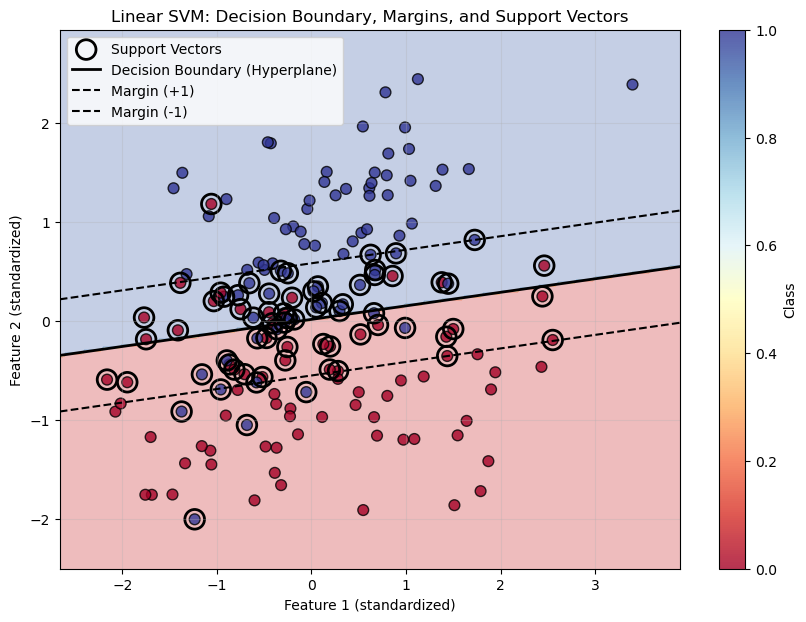

In [7]:
# 6. Visualization: Decision Boundary, Margins, and Support Vectors
# Create a mesh grid over the feature space
def plot_svm_decision_boundary(model, X, y, scaler, title="SVM Decision Boundary"):
    # We need to plot points in original scaled coordinates (X_scaled)
    # But for readability, we can plot in the scaled space since we used scaler.
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict class for each point in mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision regions
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # Plot training points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu,
                          edgecolors='k', s=60, alpha=0.8)
    
    # Plot support vectors (highlighted)
    support_vectors = model.support_vectors_
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
                s=200, linewidth=2, facecolors='none', edgecolors='k',
                label='Support Vectors')
    
    # Plot decision boundary (hyperplane) and margins
    # Decision boundary: w0*x0 + w1*x1 + b = 0
    # Margin lines: w0*x0 + w1*x1 + b = ±1
    # Solve for x1: x1 = (-w0*x0 - b ± 1) / w1
    w0, w1 = w[0], w[1]
    x0_vals = np.linspace(x_min, x_max, 100)
    
    # Hyperplane
    hyperplane = (-w0 * x0_vals - b) / w1
    # Positive margin (+1)
    margin_pos = (-w0 * x0_vals - b + 1) / w1
    # Negative margin (-1)
    margin_neg = (-w0 * x0_vals - b - 1) / w1
    
    plt.plot(x0_vals, hyperplane, 'k-', linewidth=2, label='Decision Boundary (Hyperplane)')
    plt.plot(x0_vals, margin_pos, 'k--', linewidth=1.5, label='Margin (+1)')
    plt.plot(x0_vals, margin_neg, 'k--', linewidth=1.5, label='Margin (-1)')
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('Feature 1 (standardized)')
    plt.ylabel('Feature 2 (standardized)')
    plt.title(title)
    plt.legend()
    plt.colorbar(scatter, label='Class')
    plt.grid(alpha=0.3)
    plt.show()

# Plot using the training data (scaled)
plot_svm_decision_boundary(svm_model, X_train, y_train, scaler,
                           title="Linear SVM: Decision Boundary, Margins, and Support Vectors")

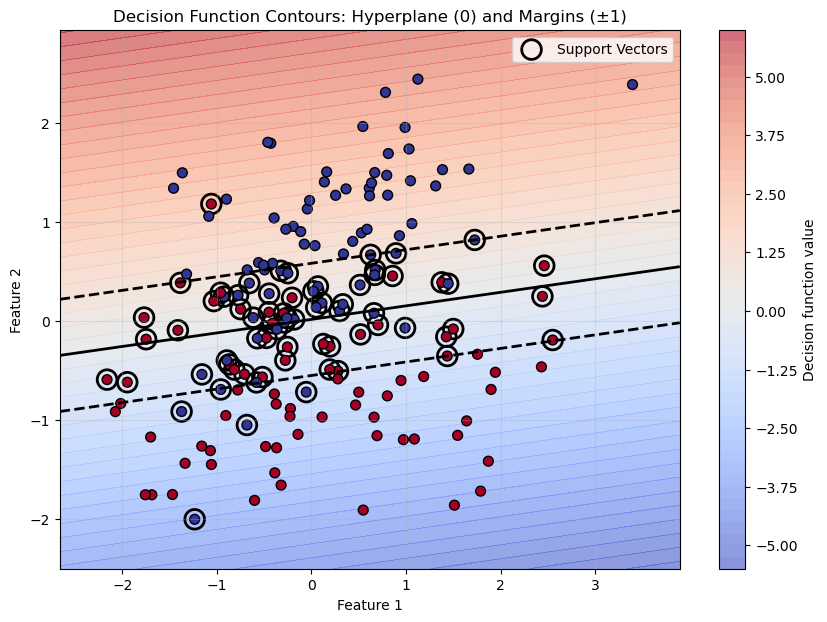

In [8]:
# 7. Additional Plot: Decision Function & Margins as Contours
# The decision_function gives the signed distance from the hyperplane.
# We can plot the contours of the decision function to see the margins.

def plot_decision_function_contours(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Compute decision function (distance to hyperplane)
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 7))
    # Plot filled contours of the decision function
    contour = plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.6)
    # Plot the zero line (hyperplane) and ±1 margins
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['k', 'k', 'k'],
                linestyles=['--', '-', '--'], linewidths=2)
    # Plot support vectors
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                s=200, facecolors='none', edgecolors='black', linewidth=2,
                label='Support Vectors')
    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=50)
    plt.colorbar(contour, label='Decision function value')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Function Contours: Hyperplane (0) and Margins (±1)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_function_contours(svm_model, X_train, y_train)

In [9]:
# 8. Explanation of Key Concepts for Students
print("\n=== Key SVM Concepts Explained ===")
print("1. Hyperplane (Decision Boundary):")
print("   The line (in 2D) or plane (in higher dimensions) that separates classes.")
print("   Equation: w·x + b = 0")
print()
print("2. Margin:")
print("   The distance between the hyperplane and the closest data points from each class.")
print("   SVM tries to maximize this margin. The margin width = 2/||w||.")
print("   The lines where w·x + b = ±1 are the 'margins'.")
print()
print("3. Support Vectors:")
print("   Data points that lie exactly on the margin (or within, if soft margin).")
print("   They 'support' the decision boundary; moving them changes the hyperplane.")
print("   In this model, the number of support vectors is", len(svm_model.support_vectors_))
print()
print("4. Decision Function:")
print("   f(x) = w·x + b. Its sign determines the predicted class.")
print("   The absolute value indicates the distance from the hyperplane.")
print()
print("5. Soft Margin (C parameter):")
print("   C = 1.0 allows some misclassifications to achieve a wider margin.")
print("   Smaller C → wider margin, more tolerance. Larger C → narrow margin, less tolerance.")


=== Key SVM Concepts Explained ===
1. Hyperplane (Decision Boundary):
   The line (in 2D) or plane (in higher dimensions) that separates classes.
   Equation: w·x + b = 0

2. Margin:
   The distance between the hyperplane and the closest data points from each class.
   SVM tries to maximize this margin. The margin width = 2/||w||.
   The lines where w·x + b = ±1 are the 'margins'.

3. Support Vectors:
   Data points that lie exactly on the margin (or within, if soft margin).
   They 'support' the decision boundary; moving them changes the hyperplane.
   In this model, the number of support vectors is 70

4. Decision Function:
   f(x) = w·x + b. Its sign determines the predicted class.
   The absolute value indicates the distance from the hyperplane.

5. Soft Margin (C parameter):
   C = 1.0 allows some misclassifications to achieve a wider margin.
   Smaller C → wider margin, more tolerance. Larger C → narrow margin, less tolerance.
